# CREATING PLOTS FOR IMAGE COMPARISON

In [17]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [15]:
def visualize_inpainting_results(
    reconstructed_dir: str,
    blending: bool,  # choose True/False (just for naming the final image)
    gt_dir: str,
    mask_dir: str,
    test_id: int,
    mask_id: int
):
    # 1. Construct file paths according to their respective naming schemes
    gt_path = os.path.join(gt_dir, f"Places365_test_{test_id:08d}.jpg")
    mask_path = os.path.join(mask_dir, f"{mask_id:06d}.jpg")
    rec_path = os.path.join(reconstructed_dir, f"Places365_test_{test_id:08d}__{mask_id:06d}.png")
    
    # Verify all files exist
    paths = {"Ground Truth": gt_path, "Mask": mask_path, "Reconstructed": rec_path}
    for name, path in paths.items():
        if not os.path.exists(path):
            print(f"Error: {name} file not found at '{path}'")
            return
            
    # 2. Load Ground Truth and Reconstructed images
    gt_img = Image.open(gt_path).convert("RGB")
    rec_img = Image.open(rec_path).convert("RGB")
    
    # 3. Load Mask and convert to boolean array
    mask_raw = Image.open(mask_path).convert("L")
    mask_bool = np.array(mask_raw) > 128  # Original: True where defect/hole is located
    # Invert 1s and 0s (True becomes False, False becomes True)
    mask_img = ~mask_bool  # Alternatively: np.logical_not(mask_bool)
    
    # 4. Create Ground Truth with Mask Applied (Defected Image)
    gt_np = np.array(gt_img)
    defect_np = gt_np.copy()
    defect_np[~mask_bool] = 255  # 0 for mask in black, 255 for mask in white
    
    # 5. Plot all four side-by-side in a single row
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(gt_img)
    axes[0].set_title("Ground Truth")
    
    # axes[1].imshow(mask_img, cmap="gray")
    # axes[1].set_title("2. Mask")
    
    axes[1].imshow(defect_np)
    axes[1].set_title("GT + Mask Applied")
    
    axes[2].imshow(rec_img)
    axes[2].set_title("Reconstructed Image")
    
    for ax in axes:
        ax.axis("off")

    
    plt.tight_layout()
    if blending == True:
        plt.savefig(f"./images_comparison/{test_id}_{mask_id}_blend.png", bbox_inches='tight')
    elif blending == False:
        plt.savefig(f"./images_comparison/{test_id}_{mask_id}_no_blend.png", bbox_inches='tight')
    else: print("IMAGE NOT SAVED: check blending boolean input")
    plt.show()

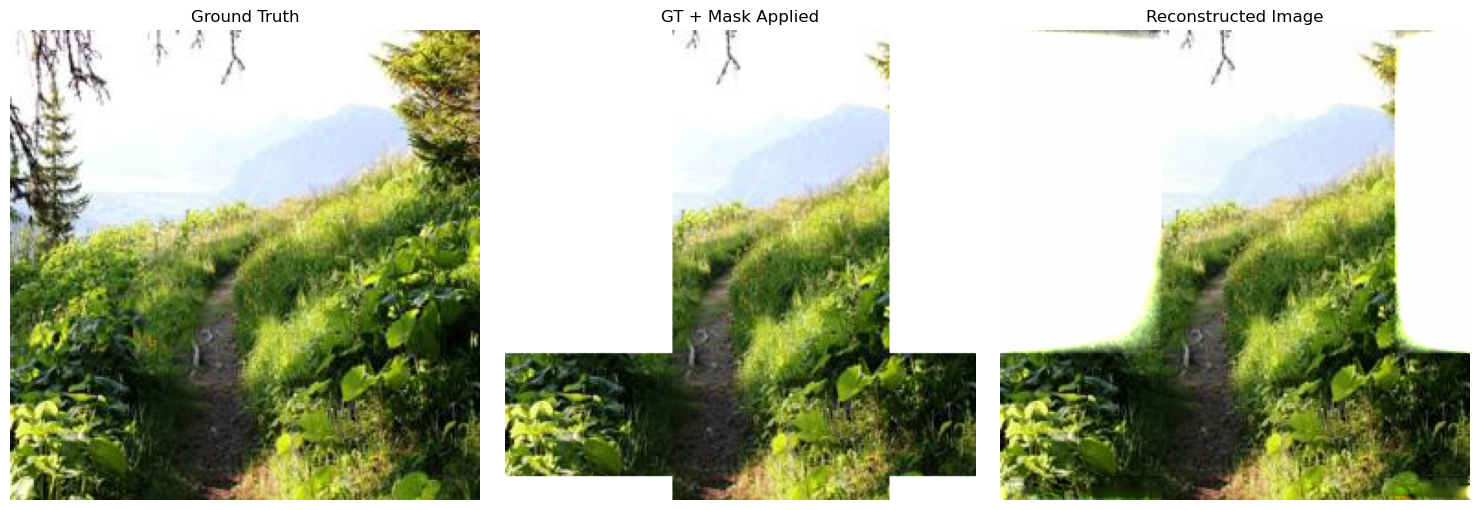

In [66]:
net_results = "/home/benedetto/Scrivania/COMPUTER VISION/project/generated_images/iizuka_200img_48masks_blending"
gt_path = "./iizuka_docker/images/"
mask_path = "./iizuka_docker/masks/masks_variety_for_iizuka/"

# Example usage:
visualize_inpainting_results(
    reconstructed_dir=net_results,
    blending=True,
    gt_dir=gt_path,
    mask_dir=mask_path,
    test_id=139,
    mask_id=23
)

Overall, the Iizuka model produces visually plausible
completions, but its behavior strongly depends on the mask
type and the amount of missing content. It generally per-
forms better on structured geometric masks such as boxes
compared to circles, possibly due to the type of regions
seen during training. The model struggles when large se-
mantic information is missing, often failing to reconstruct
coherent objects when only partial context is available (e.g.
05 017). On the other hand, it can sometimes success-
fully hallucinate plausible object structures when enough
contextual cues remain, such as partially visible buildings
(e.g. 115 017). Several typical failure modes are observed:
color inconsistencies already in the base model output (e.g.
05 043, 06 41, 07 014, 125 24, 146 15), unintended ob-
ject elongation (e.g. 06 021, 122 11), and incorrect object
removal or creation when masks overlap semantic entities
(e.g. 08 22, 104 18, 122 18, 105 017). Performance is
generally better when the surrounding scene is visually uni-
form (e.g. 125 3, 125 37), while structured patterns make
artifacts more visible to the human eye (e.g. 106 16 vs
111 017). Finally, when the masked region is large, the out-
put can differ significantly from the ground truth while still
remaining visually plausible (e.g. 112 22), highlighting the
one-to-many nature of the task.

Good results blending: 31_41, 2_42, 41_15, 160_39, 111_17

### BETTER VERSION FOR PRESENTATION

In [24]:
from typing import List, Union

def paper_plot(
    reconstructed_dir: str,
    gt_dir: str,
    mask_dir: str,
    test_ids: Union[int, List[int]],
    mask_ids: Union[int, List[int]],
    savename
):
    # Ensure inputs are lists for uniform processing
    if isinstance(test_ids, int):
        test_ids = [test_ids]
    if isinstance(mask_ids, int):
        mask_ids = [mask_ids]

    # Validate that both lists are of equal length
    if len(test_ids) != len(mask_ids):
        raise ValueError(
            f"Length mismatch: test_ids ({len(test_ids)}) and mask_ids ({len(mask_ids)}) must have the same length."
        )

    n_rows = len(test_ids)

    # Initialize a figure with N rows and 3 columns
    # squeeze=False guarantees 'axes' is always a 2D array even if N=1
    fig_width = 3.2
    fig_height = 1.05 * n_rows + 0.3  # Dynamic height according to row count
    fig, axes = plt.subplots(
        n_rows,
        3,
        figsize=(fig_width, fig_height),
        squeeze=False,
        gridspec_kw={"wspace": 0.03, "hspace": 0.05},
    )

    for i, (t_id, m_id) in enumerate(zip(test_ids, mask_ids)):
        # 1. Construct file paths
        gt_path = os.path.join(gt_dir, f"Places365_test_{t_id:08d}.jpg")
        mask_path = os.path.join(mask_dir, f"{m_id:06d}.jpg")
        rec_path = os.path.join(
            reconstructed_dir, f"Places365_test_{t_id:08d}__{m_id:06d}.png"
        )

        # Verify all files exist for the current pair
        paths = {
            "Ground Truth": gt_path,
            "Mask": mask_path,
            "Reconstructed": rec_path,
        }
        for name, path in paths.items():
            if not os.path.exists(path):
                print(
                    f"Error: {name} file not found at '{path}' (Pair index {i})"
                )
                plt.close(fig)
                return

        # 2. Load images
        gt_img = Image.open(gt_path).convert("RGB")
        rec_img = Image.open(rec_path).convert("RGB")
        mask_img = Image.open(mask_path).convert("L")

        # 3. Apply mask to Ground Truth
        mask_bool = ~(np.array(mask_img) > 128)
        gt_np = np.array(gt_img)
        defect_np = gt_np.copy()
        defect_np[mask_bool] = 255

        # 4. Plot current row
        axes[i, 0].imshow(gt_img)
        axes[i, 1].imshow(defect_np)
        axes[i, 2].imshow(rec_img)

        # Set column titles only for the very first row
        if i == 0:
            axes[i, 0].set_title("Ground Truth", fontsize=7, pad=3)
            axes[i, 1].set_title("GT with Mask", fontsize=7, pad=3)
            axes[i, 2].set_title("Inpainted Output", fontsize=7, pad=3)

        # Turn off axis labels for all subplots in this row
        for ax in axes[i]:
            ax.axis("off")
    
    #plt.tight_layout()
    plt.savefig(savename, dpi=300, bbox_inches="tight")
    plt.show()

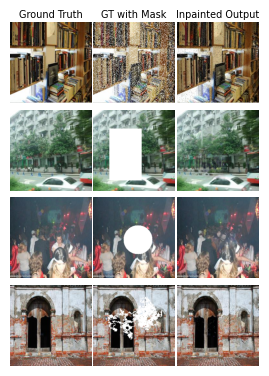

In [52]:
net_results = "/home/benedetto/Scrivania/COMPUTER VISION/project/generated_images/iizuka_200img_48masks_blending"
gt_path = "./iizuka_docker/images/"
mask_path = "./iizuka_docker/masks/masks_variety_for_iizuka/"

paper_plot(
    reconstructed_dir = net_results,
    gt_dir = gt_path,
    mask_dir = mask_path,
    test_ids=[123,74,97,178],  # ID test images
    mask_ids=[6,16,26,40],     # corresponding mask IDs
    savename="./images_comparison/all_masks_comparison.png",  # High-res export for paper
)

# STANDARD VS BLENDING IIZUKA

In [61]:
def paper_plot_iizuka_comparison(
    reconstructed_dir: str,
    blended_dir: str,
    gt_dir: str,
    mask_dir: str,
    test_ids: Union[int, List[int]],
    mask_ids: Union[int, List[int]],
    savename: str,
):
    """
    Generates a 4-column side-by-side comparison figure for inpainting results:
    1. Ground Truth
    2. Ground Truth with Mask
    3. Reconstructed Output
    4. Blended Output
    """
    # Ensure inputs are lists for uniform processing
    if isinstance(test_ids, int):
        test_ids = [test_ids]
    if isinstance(mask_ids, int):
        mask_ids = [mask_ids]

    # Validate that both lists are of equal length
    if len(test_ids) != len(mask_ids):
        raise ValueError(
            f"Length mismatch: test_ids ({len(test_ids)}) and mask_ids ({len(mask_ids)}) must have the same length."
        )

    n_rows = len(test_ids)

    # Scale width from 3.2 (3 cols) to ~4.3 (4 cols) for uniform subplot aspect ratios
    fig_width = 4.3
    fig_height = 1.05 * n_rows + 0.3  # Dynamic height according to row count
    fig, axes = plt.subplots(
        n_rows,
        4,
        figsize=(fig_width, fig_height),
        squeeze=False,
        gridspec_kw={"wspace": 0.03, "hspace": 0.05},
    )

    for i, (t_id, m_id) in enumerate(zip(test_ids, mask_ids)):
        # 1. Construct file paths
        gt_path = os.path.join(gt_dir, f"Places365_test_{t_id:08d}.jpg")
        mask_path = os.path.join(mask_dir, f"{m_id:06d}.jpg")
        rec_path = os.path.join(
            reconstructed_dir, f"Places365_test_{t_id:08d}__{m_id:06d}.png"
        )
        blended_path = os.path.join(
            blended_dir, f"Places365_test_{t_id:08d}__{m_id:06d}.png"
        )

        # Verify all files exist for the current pair
        paths = {
            "Ground Truth": gt_path,
            "Mask": mask_path,
            "Reconstructed": rec_path,
            "Blended Output": blended_path,
        }
        for name, path in paths.items():
            if not os.path.exists(path):
                print(
                    f"Error: {name} file not found at '{path}' (Pair index {i})"
                )
                plt.close(fig)
                return

        # 2. Load images
        gt_img = Image.open(gt_path).convert("RGB")
        rec_img = Image.open(rec_path).convert("RGB")
        blended_img = Image.open(blended_path).convert("RGB")
        mask_img = Image.open(mask_path).convert("L")

        # 3. Apply mask to Ground Truth
        mask_bool = ~(np.array(mask_img) > 128)
        gt_np = np.array(gt_img)
        defect_np = gt_np.copy()
        defect_np[mask_bool] = 255

        # 4. Plot current row
        axes[i, 0].imshow(gt_img)
        axes[i, 1].imshow(defect_np)
        axes[i, 2].imshow(rec_img)
        axes[i, 3].imshow(blended_img)

        # Set column titles only for the very first row
        if i == 0:
            axes[i, 0].set_title("Ground Truth", fontsize=7, pad=3)
            axes[i, 1].set_title("GT with Mask", fontsize=7, pad=3)
            axes[i, 2].set_title("Inpainted Output", fontsize=7, pad=3)
            axes[i, 3].set_title("Blended Output", fontsize=7, pad=3)

        # Turn off axis labels for all subplots in this row
        for ax in axes[i]:
            ax.axis("off")

    plt.savefig(savename, dpi=300, bbox_inches="tight")
    plt.show()

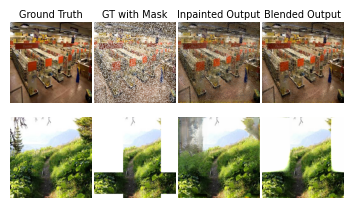

In [70]:
net_results = "/home/benedetto/Scrivania/COMPUTER VISION/project/generated_images/iizuka_200img_48masks"
net_blended = "/home/benedetto/Scrivania/COMPUTER VISION/project/generated_images/iizuka_200img_48masks_blending"
gt_path = "./iizuka_docker/images/"
mask_path = "./iizuka_docker/masks/masks_variety_for_iizuka/"

paper_plot_iizuka_comparison(
    reconstructed_dir = net_results,
    blended_dir = net_blended,
    gt_dir = gt_path,
    mask_dir = mask_path,
    test_ids=[135,139],  # ID test images
    mask_ids=[7,23],     # corresponding mask IDs
    savename="./images_comparison/iizuka_blending_comparison_2.png",  # High-res export for paper
)